In [1]:
import sys
import tensorflow as tf

print(f"TensorFlow ver is {tf.__version__}")
print(f"PYTHON ver is {sys.version}")
print("GPU is","available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TensorFlow ver is 2.10.0
PYTHON ver is 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
GPU is available


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 0) Config
# ============================================================
DATA_DIR = "database"
DATA_FILE = "cmall_remove_duplicate_m_all.csv"   # RAW(정규화 전) csv

QUALITY_MODEL_PATH = "best_model_residue.h5"      # pretrained quality ANN (frozen)
POLICY_SAVE_PATH   = "best_policy_net.keras"     # save trained policy net (Keras v3)

SCALER_X_PATH = "scaler_x_38.pkl"                # for quality inputs (38)
SCALER_Y_PATH = "scaler_y_1.pkl"                 # for residue (real unit)

RANDOM_STATE = 42
BATCH_SIZE = 1024
EPOCHS = 500

TARGET_RESIDUE_DEFAULT = 8.0

# Δu bound in normalized space (변수별로 튜닝 권장)
DELTA_MAX_DEFAULT = 0.2

# Loss weights (규제항)
LAM_L2 = 0.0
LAM_L1 = 0.0
HUBER_DELTA = 1.0

LR = 5e-4
PATIENCE = 50

In [3]:
# ============================================================
# 1) Column definitions
# ============================================================

CONTROL_COLS_9 = [
    "RP_roller_p1",
    "RP_roller_p2",
    "RP_sep_rpm",
    "RP_sep_fan_damper",
    "RP_sep_BF_damper",
    "mill_BF_damper",
    "mill_sep_rpm",
    "mill_sep_fan_damper",
    "grind_aid",
]
assert len(CONTROL_COLS_9) == 9

MONITOR_COLS_28 = [
    # existing monitoring (23)
    "RP_spac",
    "RP_skew",
    "RP_roller_energy1",
    "RP_roller_energy2",
    "RP_roller_vib",
    "RP_BE_energy1",
    "RP_BE_energy2",
    "RP_sep_BF_pressure",
    "dosing_BE_energy",
    "mill_feed_c",
    "mill_feed_cir",
    "mill_energy",
    "mill_in_temp",
    "mill_out_temp",
    "mill_BE_energy",
    "mill_out_gas_temp",
    "mill_out_mater_temp",
    "mill_BF_pressure",
    "mill_sep_BF_pressure",
    "mill_sep_BF_fan_damper",
    "final_BE_1",
    "final_BE_2",
    "final_mater_temp",
    # feed composition moved to monitoring (4)
    "feed_clinker",
    "feed_gypsum",
    "feed_slag",
    "feed_FA",
    # total feed moved to monitoring (1)
    "feed_total",
]
assert len(MONITOR_COLS_28) == 28

# ---- Quality vs Policy 품질 컬럼 분리
QUALITY_PREV_COL   = "residue"        # quality ANN input
POLICY_CUR_COL     = "residue"        # policy ANN input (current quality)
TARGET_QUALITY_COL = "residue_target" # policy ANN input & training target (real unit)

# ---- Quality model input (MUST match pretrained quality model training)
QUALITY_INPUT_COLS = CONTROL_COLS_9 + MONITOR_COLS_28 + [QUALITY_PREV_COL]
assert len(QUALITY_INPUT_COLS) == 38

# ---- Policy input (NOW 39): monitor 28 + current_quality 1 + current_control 9 + target 1
POLICY_INPUT_DIM = 28 + 1 + 9 + 1
assert POLICY_INPUT_DIM == 39

print("QUALITY_INPUT_DIM:", len(QUALITY_INPUT_COLS))
print("POLICY_INPUT_DIM :", POLICY_INPUT_DIM)


QUALITY_INPUT_DIM: 38
POLICY_INPUT_DIM : 39


In [4]:
# ============================================================
# 2) Load raw data
# ============================================================
csv_path = os.path.join(DATA_DIR, DATA_FILE)
df = pd.read_csv(csv_path)

# Ensure target column
if TARGET_QUALITY_COL not in df.columns:
    df[TARGET_QUALITY_COL] = TARGET_RESIDUE_DEFAULT

required_cols = list(set(
    QUALITY_INPUT_COLS +          # includes residue_prev
    [POLICY_CUR_COL] +            # includes residue
    [TARGET_QUALITY_COL]          # includes residue_target
))

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in CSV: {missing_cols}")

df = df.dropna(subset=required_cols).reset_index(drop=True)
print(f"Loaded raw data: {df.shape} from {csv_path}")
print("Target unique count:", df[TARGET_QUALITY_COL].nunique())


Loaded raw data: (60572, 43) from database\cmall_remove_duplicate_m_all.csv
Target unique count: 1


In [5]:
# ============================================================
# 3) Split indices
# ============================================================
idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=RANDOM_STATE)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, random_state=RANDOM_STATE)

print(f"Split: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}")

Split: train=42400, val=9086, test=9086


In [6]:
# ============================================================
# 4) Fit scalers (train only) & save
# ============================================================

# scaler_x: quality input 38개 (controls+monitor+residue_prev) ==================================================
scaler_x = MinMaxScaler(feature_range=(0.0, 1.0))
scaler_x.fit(df.loc[idx_all, QUALITY_INPUT_COLS].to_numpy(dtype=np.float32))

# 2) residue / residue_prev 컬럼 인덱스 찾기
residue_idx = QUALITY_INPUT_COLS.index("residue")

# 3) 강제 min/max 지정
CUSTOM_MIN = 3.4
CUSTOM_MAX = 11.5

for idx in [residue_idx]:     #for idx in [residue_idx, residue_prev_idx]:
    scaler_x.data_min_[idx] = CUSTOM_MIN
    scaler_x.data_max_[idx] = CUSTOM_MAX
    scaler_x.data_range_[idx] = CUSTOM_MAX - CUSTOM_MIN
    scaler_x.scale_[idx] = 1.0 / (CUSTOM_MAX - CUSTOM_MIN)
    scaler_x.min_[idx] = -CUSTOM_MIN / (CUSTOM_MAX - CUSTOM_MIN)

print("Custom scaling applied to residue columns")

# scaler_y: residue real unit (policy current/target, and inverse for printing) ================================
scaler_y = MinMaxScaler(feature_range=(0.0, 1.0))
scaler_y.fit(df.loc[idx_all, [POLICY_CUR_COL]].to_numpy(dtype=np.float32))

# 2) residue / residue_prev 컬럼 인덱스 찾기
residue_idx = POLICY_CUR_COL.index("residue")

# 3) 강제 min/max 지정
CUSTOM_MIN = 3.4
CUSTOM_MAX = 11.5

for idx in [residue_idx]:     #for idx in [residue_idx, residue_prev_idx]:
    scaler_y.data_min_[idx] = CUSTOM_MIN
    scaler_y.data_max_[idx] = CUSTOM_MAX
    scaler_y.data_range_[idx] = CUSTOM_MAX - CUSTOM_MIN
    scaler_y.scale_[idx] = 1.0 / (CUSTOM_MAX - CUSTOM_MIN)
    scaler_y.min_[idx] = -CUSTOM_MIN / (CUSTOM_MAX - CUSTOM_MIN)

print("Custom scaling applied to residue columns")

joblib.dump(scaler_x, SCALER_X_PATH)
joblib.dump(scaler_y, SCALER_Y_PATH)

print("Saved scalers:", SCALER_X_PATH, SCALER_Y_PATH)

Custom scaling applied to residue columns
Custom scaling applied to residue columns
Saved scalers: scaler_x_38.pkl scaler_y_1.pkl


In [7]:
# ============================================================
# 5) Load pretrained quality model (FROZEN)
# ============================================================
quality_model = tf.keras.models.load_model(QUALITY_MODEL_PATH)
quality_model.trainable = False

print("Quality model input/output:", quality_model.input_shape, quality_model.output_shape)

Quality model input/output: (None, 38) (None, 1)


In [8]:
# ============================================================
# 6) Build normalized arrays for policy training (39(+1)-D)
# ============================================================

# ---- raw arrays
u_cur_raw  = df[CONTROL_COLS_9].to_numpy(dtype=np.float32)            # (N,9)
mon_raw    = df[MONITOR_COLS_28].to_numpy(dtype=np.float32)           # (N,28)
qprev_raw  = df[[QUALITY_PREV_COL]].to_numpy(dtype=np.float32)        # (N,1)  quality prev
qcur_raw   = df[[POLICY_CUR_COL]].to_numpy(dtype=np.float32)          # (N,1)  policy current
yT_raw     = df[[TARGET_QUALITY_COL]].to_numpy(dtype=np.float32)      # (N,1)  policy target

# ---- quality input raw (38): [u_cur, mon, qprev]
Xq_raw = np.concatenate([u_cur_raw, mon_raw, qprev_raw], axis=1)      # (N,38)

# ---- normalize quality input via scaler_x (0~1)
Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)               # (N,38)
u_cur_norm = Xq_norm[:, :9]                                           # (N,9)
mon_norm   = Xq_norm[:, 9:9+28]                                       # (N,28)
qprev_norm = Xq_norm[:, 9+28:9+28+1]                                  # (N,1) normalized residue_prev space

# ---- normalize policy current & target via scaler_y (0~1)
qcur_norm = scaler_y.transform(qcur_raw).astype(np.float32)           # (N,1)
yT_norm   = scaler_y.transform(yT_raw).astype(np.float32)             # (N,1)

# ---- policy input (39(+1)):
# [mon_norm(28), qcur_norm(1), u_cur_norm(9), yT_norm(1), qprev_norm(1)]
Xp = np.concatenate([mon_norm, qcur_norm, u_cur_norm, yT_norm, qprev_norm], axis=1).astype(np.float32)
assert Xp.shape[1] == POLICY_INPUT_DIM + 1

# ---- split
Xp_train, yT_train = Xp[idx_train], yT_norm[idx_train]
Xp_val,   yT_val   = Xp[idx_val],   yT_norm[idx_val]
Xp_test,  yT_test  = Xp[idx_test],  yT_norm[idx_test]

print("Policy arrays:",
      "train", Xp_train.shape, yT_train.shape,
      "| val", Xp_val.shape, yT_val.shape,
      "| test", Xp_test.shape, yT_test.shape)

Policy arrays: train (42400, 40) (42400, 1) | val (9086, 40) (9086, 1) | test (9086, 40) (9086, 1)


In [9]:
# ============================================================
# 7) tf.data datasets
# ============================================================
train_ds = tf.data.Dataset.from_tensor_slices((Xp_train, yT_train)) \
    .shuffle(20000, seed=RANDOM_STATE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((Xp_val, yT_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((Xp_test, yT_test)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

print("Datasets ready.")

Datasets ready.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

# ============================================================
# 8) Build policy network (delta-u for 9 controls)
# ============================================================
def build_policy_model(input_shape):
    model = Sequential([
        Dense(128, activation='swish',
              kernel_initializer='glorot_uniform',
              input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.1),

        Dense(1024, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(2048, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(2048, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1024, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(9, activation='tanh', name='delta_raw')  # in [-1, 1]
    ])
    return model

policy_net = build_policy_model((POLICY_INPUT_DIM,))
policy_net.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               5120      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1024)              132096    
                                                                 
 batch_normalization_1 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 1024)              0

In [11]:
# ============================================================
# 9) Delta bounds (per-control) in normalized space
# ============================================================

DELTA_MAX = np.array([DELTA_MAX_DEFAULT] * 9, dtype=np.float32)  # (9,)
DELTA_MAX_TF = tf.constant(DELTA_MAX.reshape(1, -1), dtype=tf.float32)

print("DELTA_MAX:", DELTA_MAX)


DELTA_MAX: [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]


In [12]:
# ============================================================
# 10) Wrapper model: frozen quality model + trainable policy model
#     Xp layout (40):
#       [mon(28), qcur(1), u_cur(9), y_target(1), qprev(1)]
#     quality input (38):
#       [u_new(9), mon(28), qprev(1)]
# ============================================================
class ControlRecommender(tf.keras.Model):
    def __init__(self, policy_net: tf.keras.Model, quality_model: tf.keras.Model,
                 lam_l2: float = 1.0, lam_l1: float = 0.1, huber_delta: float = 1.0):
        super().__init__()
        self.policy_net = policy_net
        self.quality_model = quality_model  # frozen

        self.lam_l2 = lam_l2
        self.lam_l1 = lam_l1
        self.huber_delta = huber_delta

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.pred_loss_tracker = tf.keras.metrics.Mean(name="pred_loss")
        self.delta_l2_tracker = tf.keras.metrics.Mean(name="delta_l2")
        self.delta_l1_tracker = tf.keras.metrics.Mean(name="delta_l1")

    @property
    def metrics(self):
        return [self.loss_tracker, self.pred_loss_tracker,
                self.delta_l2_tracker, self.delta_l1_tracker]

    def call(self, Xp_batch, training=False):
        # Xp layout
        mon   = Xp_batch[:, 0:28]
        qcur  = Xp_batch[:, 28:29]    # policy input only (not used in quality input)
        u_cur = Xp_batch[:, 29:38]
        yT    = Xp_batch[:, 38:39]    # policy input only (loss uses yT separately)
        qprev = Xp_batch[:, 39:40]    # IMPORTANT: quality input prev quality

        # policy input: qprev 제외한 39차원만 사용
        Xp_no_prev = Xp_batch[:, 0:39]  # = [mon(28), qcur(1), u_cur(9), yT(1)]

        # policy_net outputs delta_raw in [-1,1]
        delta_raw = self.policy_net(Xp_no_prev, training=training)  # (B,9)
        delta = delta_raw * DELTA_MAX_TF                          # bounded
        u_new = tf.clip_by_value(u_cur + delta, 0.0, 1.0)         # (B,9)

        # quality input (38): [u_new(9), mon(28), qprev(1)]
        Xq_new = tf.concat([u_new, mon, qprev], axis=1)           # (B,38)
        y_pred = self.quality_model(Xq_new, training=False)       # (B,1)

        return u_new, y_pred, delta

    def train_step(self, data):
        Xp_batch, y_target_batch = data

        with tf.GradientTape() as tape:
            _, y_pred, delta = self(Xp_batch, training=True)

            pred_loss = tf.reduce_mean(
                tf.keras.losses.huber(y_target_batch, y_pred, delta=self.huber_delta)
            )

            delta_l2 = tf.reduce_mean(tf.reduce_sum(tf.square(delta), axis=1))
            delta_l1 = tf.reduce_mean(tf.reduce_sum(tf.abs(delta), axis=1))

            loss = pred_loss + self.lam_l2 * delta_l2 + self.lam_l1 * delta_l1

        grads = tape.gradient(loss, self.policy_net.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.policy_net.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.pred_loss_tracker.update_state(pred_loss)
        self.delta_l2_tracker.update_state(delta_l2)
        self.delta_l1_tracker.update_state(delta_l1)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        Xp_batch, y_target_batch = data

        _, y_pred, delta = self(Xp_batch, training=False)

        pred_loss = tf.reduce_mean(
            tf.keras.losses.huber(y_target_batch, y_pred, delta=self.huber_delta)
        )
        delta_l2 = tf.reduce_mean(tf.reduce_sum(tf.square(delta), axis=1))
        delta_l1 = tf.reduce_mean(tf.reduce_sum(tf.abs(delta), axis=1))

        loss = pred_loss + self.lam_l2 * delta_l2 + self.lam_l1 * delta_l1

        self.loss_tracker.update_state(loss)
        self.pred_loss_tracker.update_state(pred_loss)
        self.delta_l2_tracker.update_state(delta_l2)
        self.delta_l1_tracker.update_state(delta_l1)

        return {m.name: m.result() for m in self.metrics}

In [13]:
# ============================================================
# 11) Train policy (recommender)
# ============================================================
quality_model.trainable = False

recommender = ControlRecommender(
    policy_net=policy_net,
    quality_model=quality_model,
    lam_l2=LAM_L2,
    lam_l1=LAM_L1,
    huber_delta=HUBER_DELTA
)

recommender.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True
)

history = recommender.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

print("\nEvaluation on test set:")
recommender.evaluate(test_ds, verbose=1)

# ---- Save ONLY policy_net (권장)
policy_net.save(POLICY_SAVE_PATH)
print("Saved policy_net to:", POLICY_SAVE_PATH)

Epoch 1/500
42/42 [==============================] - 4s 37ms/step - loss: 8.3435e-04 - pred_loss: 8.3435e-04 - delta_l2: 0.2295 - delta_l1: 1.3354 - val_loss: 0.0101 - val_pred_loss: 0.0101 - val_delta_l2: 0.0989 - val_delta_l1: 0.8760
Epoch 2/500
42/42 [==============================] - 1s 26ms/step - loss: 3.4504e-04 - pred_loss: 3.4504e-04 - delta_l2: 0.2413 - delta_l1: 1.3791 - val_loss: 0.0087 - val_pred_loss: 0.0087 - val_delta_l2: 0.1585 - val_delta_l1: 1.1113
Epoch 3/500
42/42 [==============================] - 1s 26ms/step - loss: 2.8382e-04 - pred_loss: 2.8382e-04 - delta_l2: 0.2458 - delta_l1: 1.3969 - val_loss: 0.0082 - val_pred_loss: 0.0082 - val_delta_l2: 0.1936 - val_delta_l1: 1.2470
Epoch 4/500
42/42 [==============================] - 1s 26ms/step - loss: 2.4289e-04 - pred_loss: 2.4289e-04 - delta_l2: 0.2528 - delta_l1: 1.4238 - val_loss: 0.0076 - val_pred_loss: 0.0076 - val_delta_l2: 0.2221 - val_delta_l1: 1.3703
Epoch 5/500
42/42 [==============================] - 1s 

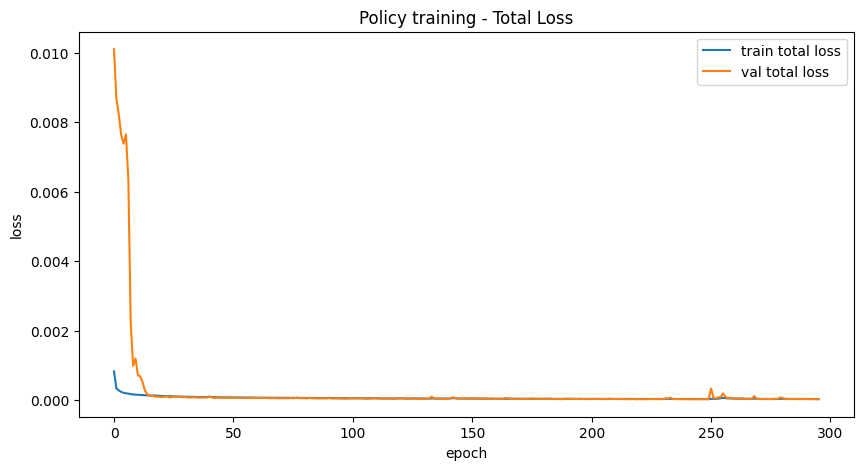

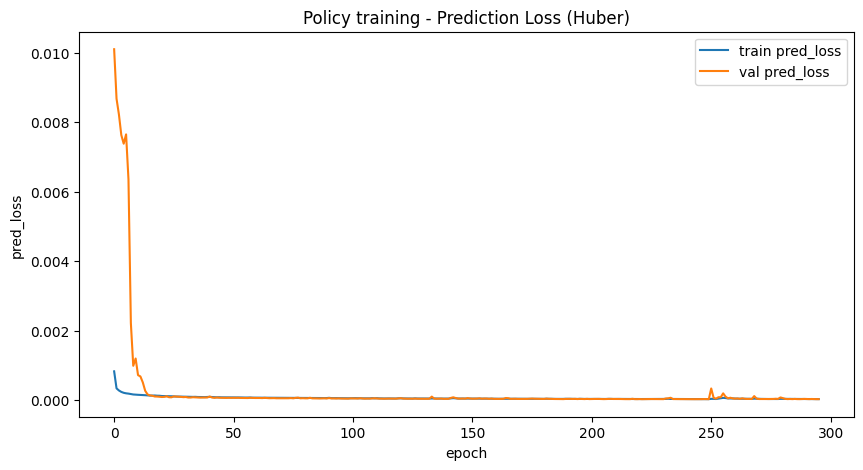

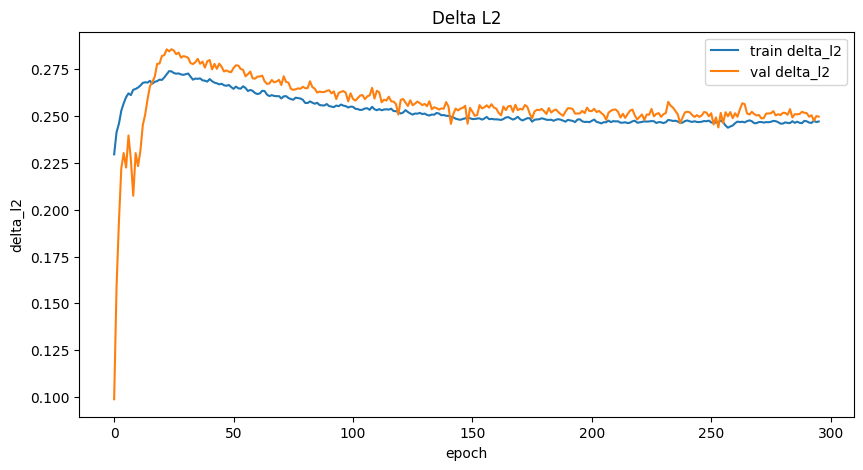

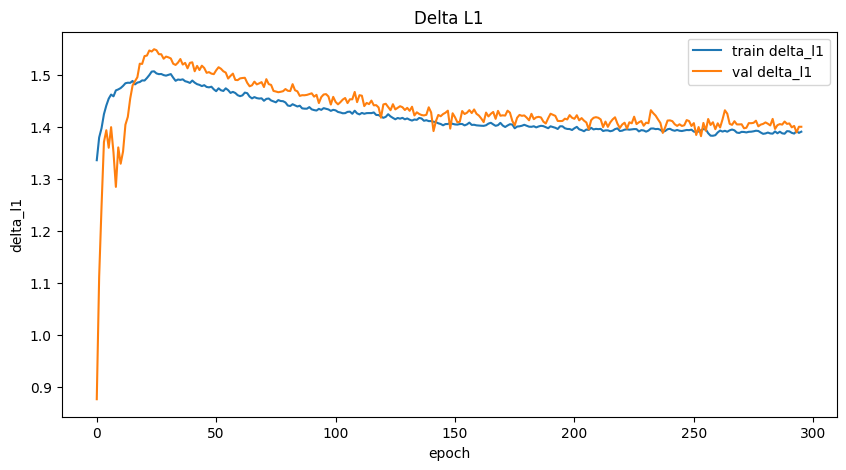

In [14]:
# ============================================================
# 12) Plot training curves
# ============================================================
hist = history.history

plt.figure(figsize=(10,5))
plt.plot(hist["loss"], label="train total loss")
plt.plot(hist["val_loss"], label="val total loss")
plt.title("Policy training - Total Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

# pred_loss도 기록되어 있으면 같이 출력
if "pred_loss" in hist:
    plt.figure(figsize=(10,5))
    plt.plot(hist["pred_loss"], label="train pred_loss")
    plt.plot(hist.get("val_pred_loss", []), label="val pred_loss")
    plt.title("Policy training - Prediction Loss (Huber)")
    plt.xlabel("epoch")
    plt.ylabel("pred_loss")
    plt.legend()
    plt.show()

# 규제항도 기록되어 있으면 출력
if "delta_l2" in hist:
    plt.figure(figsize=(10,5))
    plt.plot(hist["delta_l2"], label="train delta_l2")
    plt.plot(hist.get("val_delta_l2", []), label="val delta_l2")
    plt.title("Delta L2")
    plt.xlabel("epoch")
    plt.ylabel("delta_l2")
    plt.legend()
    plt.show()

if "delta_l1" in hist:
    plt.figure(figsize=(10,5))
    plt.plot(hist["delta_l1"], label="train delta_l1")
    plt.plot(hist.get("val_delta_l1", []), label="val delta_l1")
    plt.title("Delta L1")
    plt.xlabel("epoch")
    plt.ylabel("delta_l1")
    plt.legend()
    plt.show()


In [15]:
# ============================================================
# 13) Quick reload check
# ============================================================
policy_net_loaded = tf.keras.models.load_model(POLICY_SAVE_PATH)
print("Loaded policy_net:", POLICY_SAVE_PATH)
print("Policy output shape:", policy_net_loaded.output_shape)

Loaded policy_net: best_policy_net.keras
Policy output shape: (None, 9)


In [16]:
# ------------------------------------------------
# Policy effect check on test samples
# (normalized + real scale)  -- Policy 39D, Xp is 40 (last = qprev)
# ------------------------------------------------
def evaluate_policy_effect_with_real_scale_39policy(
    policy_net,
    quality_model,
    dataset,
    scaler_y,
    DELTA_MAX_TF,
    n_skip_batches=1,
    n_batches=1
):
    err_before_norm = []
    err_after_norm  = []

    err_before_real = []
    err_after_real  = []

    for Xp_batch, y_target_norm in dataset.skip(n_skip_batches).take(n_batches):

        # -------------------------
        # Parse Xp_batch (B,40)
        # layout: [mon(28), qcur(1), u_cur(9), yT(1), qprev(1)]
        # -------------------------
        mon   = Xp_batch[:, 0:28]
        qcur  = Xp_batch[:, 28:29]     # policy input only (not for quality)
        u_cur = Xp_batch[:, 29:38]
        yT    = Xp_batch[:, 38:39]     # policy input only
        qprev = Xp_batch[:, 39:40]     # quality input prev quality

        # -------------------------
        # BEFORE policy (current control)
        # quality input: [u_cur, mon, qprev]  -> (B,38)
        # -------------------------
        Xq_cur = tf.concat([u_cur, mon, qprev], axis=1)
        y_pred_cur_norm = quality_model(Xq_cur, training=False)  # (B,1)

        # -------------------------
        # AFTER policy
        # policy input: first 39 dims only
        # Xp_no_prev = [mon, qcur, u_cur, yT]
        # -------------------------
        Xp_no_prev = Xp_batch[:, 0:39]  # (B,39)
        delta_raw = policy_net(Xp_no_prev, training=False)  # (B,9) in [-1,1]
        delta = delta_raw * DELTA_MAX_TF                    # bounded in normalized space
        u_new = tf.clip_by_value(u_cur + delta, 0.0, 1.0)   # (B,9)

        Xq_new = tf.concat([u_new, mon, qprev], axis=1)     # (B,38)
        y_pred_new_norm = quality_model(Xq_new, training=False)  # (B,1)

        # -------------------------
        # Normalized errors (0~1)
        # -------------------------
        err_b_norm = tf.abs(y_pred_cur_norm - y_target_norm)
        err_a_norm = tf.abs(y_pred_new_norm - y_target_norm)

        err_before_norm.append(err_b_norm.numpy())
        err_after_norm.append(err_a_norm.numpy())

        # -------------------------
        # Real-scale (Residue) errors
        # -------------------------
        y_target_real   = scaler_y.inverse_transform(y_target_norm.numpy())
        y_pred_cur_real = scaler_y.inverse_transform(y_pred_cur_norm.numpy())
        y_pred_new_real = scaler_y.inverse_transform(y_pred_new_norm.numpy())

        err_b_real = np.abs(y_pred_cur_real - y_target_real)
        err_a_real = np.abs(y_pred_new_real - y_target_real)

        err_before_real.append(err_b_real)
        err_after_real.append(err_a_real)

    # batch들 누적 후 평균
    err_b_n = float(np.mean(np.concatenate(err_before_norm, axis=0)))
    err_a_n = float(np.mean(np.concatenate(err_after_norm, axis=0)))
    err_b_r = float(np.mean(np.concatenate(err_before_real, axis=0)))
    err_a_r = float(np.mean(np.concatenate(err_after_real, axis=0)))

    return err_b_n, err_a_n, err_b_r, err_a_r


# 실행 예시
err_b_n, err_a_n, err_b_r, err_a_r = evaluate_policy_effect_with_real_scale_39policy(
    policy_net=policy_net,          # 또는 policy_net_loaded
    quality_model=quality_model,
    dataset=test_ds,
    scaler_y=scaler_y,
    DELTA_MAX_TF=DELTA_MAX_TF,
    n_skip_batches=3,
    n_batches=4
)

print("=== Policy Effect Evaluation (Policy 39D) ===")
print(f"[Normalized]")
print(f"  Mean |error| BEFORE policy : {err_b_n:.6f}")
print(f"  Mean |error| AFTER  policy : {err_a_n:.6f}")
if err_b_n > 1e-12:
    print(f"  Improvement ratio          : {(1 - err_a_n/err_b_n)*100:.2f}%")
else:
    print("  Improvement ratio          : N/A (baseline too small)")

print()
print(f"[Real Residue scale]")
print(f"  Mean |error| BEFORE policy : {err_b_r:.2f} Residue")
print(f"  Mean |error| AFTER  policy : {err_a_r:.2f} Residue")
print(f"  Improvement                : {(err_b_r - err_a_r):.2f} Residue")


=== Policy Effect Evaluation (Policy 39D) ===
[Normalized]
  Mean |error| BEFORE policy : 0.096709
  Mean |error| AFTER  policy : 0.004402
  Improvement ratio          : 95.45%

[Real Residue scale]
  Mean |error| BEFORE policy : 0.78 Residue
  Mean |error| AFTER  policy : 0.04 Residue
  Improvement                : 0.75 Residue


In [17]:
import joblib

x_scaler = joblib.load("scaler_x_38.pkl")

print("x_scaler.data_min_ :", x_scaler.data_min_)
print("x_scaler.data_max_ :", x_scaler.data_max_)
print("x_scaler.data_range_ :", x_scaler.data_range_)

x_scaler.data_min_ : [ 0.000e+00  0.000e+00  2.740e+02  7.500e+01  0.000e+00  2.000e+00
  6.500e+01  8.000e+01  5.500e+00  5.500e+00  0.000e+00  9.000e-01
  9.000e-01  0.000e+00  0.000e+00  7.000e+00 -6.400e+02 -1.900e+01
 -2.890e+02 -6.940e+02  1.100e+01 -1.000e+00  3.000e+00 -6.100e+01
 -1.190e+02 -1.580e+02 -4.590e+02 -3.820e+02  2.000e+01 -6.600e+01
  0.000e+00  1.000e+01  1.200e+02  5.000e-01  0.000e+00  0.000e+00
  1.376e+02  3.400e+00]
x_scaler.data_max_ : [ 1.910e+02  1.800e+02  6.960e+02  1.000e+02  8.800e+01  7.500e+01
  1.312e+03  1.000e+02  1.669e+03  6.700e+01  1.100e+01  1.449e+03
  5.150e+02  1.510e+02  7.520e+02  8.880e+02  0.000e+00  4.470e+02
  9.390e+02  8.527e+03  1.769e+03  5.530e+02  6.690e+02  7.320e+02
  1.405e+03  9.100e+03  0.000e+00 -2.600e+00  7.000e+01  8.810e+02
  8.740e+02  1.001e+03  2.024e+02  1.570e+01  2.020e+01  1.700e+01
  2.341e+02  1.150e+01]
x_scaler.data_range_ : [1.9100000e+02 1.8000000e+02 4.2200000e+02 2.5000000e+01 8.8000000e+01
 7.3000000e+

In [18]:
y_scaler = joblib.load("scaler_y_1.pkl")

print("y_scaler.data_min_ :", y_scaler.data_min_)
print("y_scaler.data_max_ :", y_scaler.data_max_)
print("y_scaler.data_range_ :", y_scaler.data_range_)

y_scaler.data_min_ : [3.4]
y_scaler.data_max_ : [11.5]
y_scaler.data_range_ : [8.1]
